In [2]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from pandas import DataFrame
from analytics.metrics.time import TimeMetrics
from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

In [29]:
from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor
from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor, CodeBenchAddParentEventIDs
from analytics.preprocessors.codeworkout import CodeWorkoutExtractErrorTypesPreprocessor
from analytics.ps2_dataset import SortPreprocessor
from spec.enums import EventType

config_path = None
problem_id_col = None
timestamp_col = None
idle_gap = None
break_gap = None
proprocessing_steps = []
link_preprocessing_steps = []
submit_event = EventType.Submit
grades_link_table = "Subject"
grades_col = None
start_time = None
early_percentage = None
compile_error_type_col = Cols.CompileMessageType
compile_event = EventType.Compile
compile_error_event = EventType.CompileError

edwards2021_config = {
    "config_path": "sample_data_configs/edwards2021.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        TimeStampToDateTimePreprocessor(),
        SortPreprocessor()
    ],
}

cwo_s19_config = {
    "config_path": "sample_data_configs/cwo_s19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.33,
}

cwo_f19_config = {
    "config_path": "sample_data_configs/cwo_f19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor(),
        CodeWorkoutExtractErrorTypesPreprocessor(),
    ],
    "submit_event": EventType.RunProgram,
    "grades_col": "X-Grade",
    "early_percentage": 0.25,
}

codebench2024_config = {
    "config_path": "sample_data_configs/codebench2024.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
    "main_table_preprocessing_steps": [
        CodeBenchAddParentEventIDs(),
    ],
    "grades_link_table": "CourseSubject",
    "grades_col": "final-grade",
    "start_time": "2024-09-01 00:00:00",
    "early_percentage": 0.28,
    "compile_error_type_col": "ProgramErrorOutput",
    "compile_event": EventType.Submit,
    "compile_error_event": EventType.RunTest,
}

# config = cwo_f19_config
config = codebench2024_config
# config = edwards2021_config
locals().update(config)

In [4]:
from database.config import PS2DataConfig

spec = PS2Versions.v1_0.load()

data_config = PS2DataConfig.from_yaml(config_path, spec)


In [5]:
from analytics.ps2_dataset import PS2Dataset

dataset = PS2Dataset(spec, data_config)
for i, step in enumerate(proprocessing_steps):
    dataset.main_table_preprocessors.insert(i, step)
for i, step in enumerate(link_preprocessing_steps):
    dataset.link_table_preprocessors.insert(i, step)

In [6]:
main_table = dataset.get_main_table()
main_table.head()

,EventID,EventType,Order,SubjectID,CodeStateID,ProjectID,ToolInstances,ServerTimestamp,AssignmentID,ProblemID,...,ExecutionID,ExecutionResult,X-ExecutionTime,ProgramInput,ProgramOutput,ProgramErrorOutput,EditType,X-InsertText,SourceLocation,CodeStateSection
0,1224181,File.Focus,0,1837898832,NaN,NaN,Python 3.8.5,2024-05-12 15:57:04.334,4.070595e+09,9.529734e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main.py
1,1224182,X-File.Blur,1,1837898832,NaN,NaN,Python 3.8.5,2024-05-12 15:57:36.562,4.070595e+09,9.529734e+07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main.py
2,1217446,File.Focus,2,1837898832,NaN,NaN,Python 3.8.5,2024-05-12 15:59:19.589,4.070595e+09,1.471865e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,main.py
3,1217448,File.Edit,3,1837898832,NaN,NaN,Python 3.8.5,2024-05-12 15:59:23.102,4.070595e+09,1.471865e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,Insert,i,Text:0,main.py
4,1217445,File.Edit,4,1837898832,NaN,NaN,Python 3.8.5,2024-05-12 15:59:23.209,4.070595e+09,1.471865e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,Insert,f,Text:1,main.py


In [7]:
bad_assignment_ids = [407610653, 1147927607, 1407437764]
main_table = main_table[~main_table[Cols.AssignmentID].isin(bad_assignment_ids)]

In [8]:
if start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= start_time]

In [9]:
if "X-ClassID" in main_table.columns:
    class_counts = main_table["X-ClassID"].value_counts()
    print(class_counts)
    min_count = 1000
    invalid_class_ids = class_counts[class_counts < min_count].index
    print(f"Removing classes with less than {min_count} submissions: {invalid_class_ids}")
    main_table = main_table[~main_table["X-ClassID"].isin(invalid_class_ids) & ~main_table["X-ClassID"].isna()]

X-ClassID
2.298943e+09    1204023
3.648409e+09    1101398
3.758479e+09    1037972
9.455914e+08     844736
2.607741e+09     422938
1.349132e+09     243459
9.197531e+08        387
4.049260e+09        311
2.248340e+09          2
Name: count, dtype: int64
Removing classes with less than 1000 submissions: Index([919753123.0, 4049259557.0, 2248339634.0], dtype='float64', name='X-ClassID')


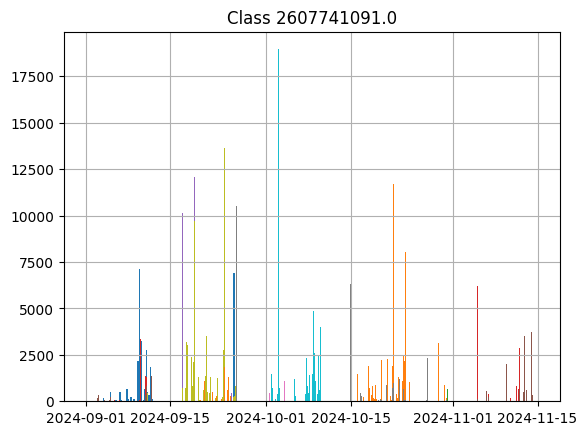

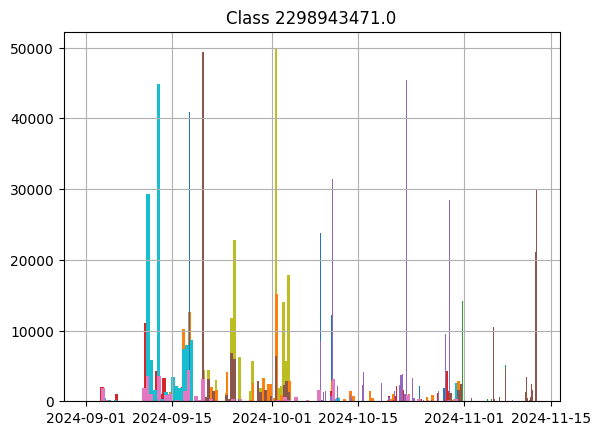

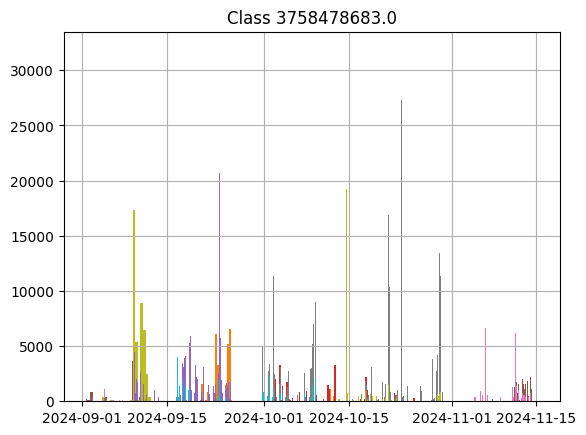

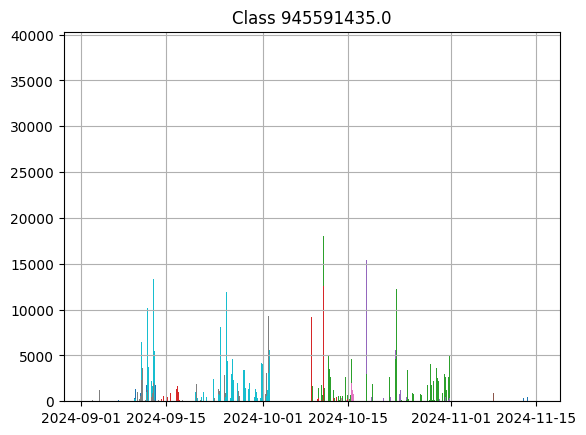

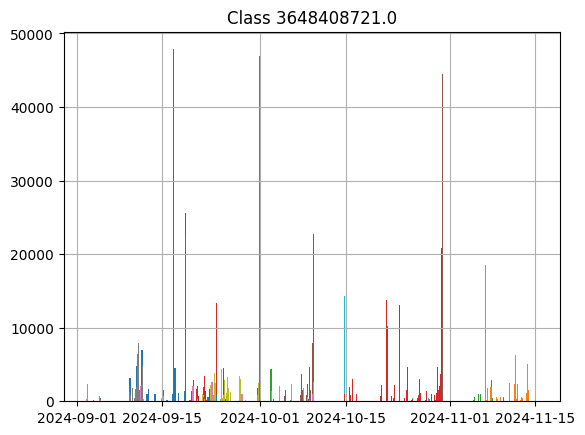

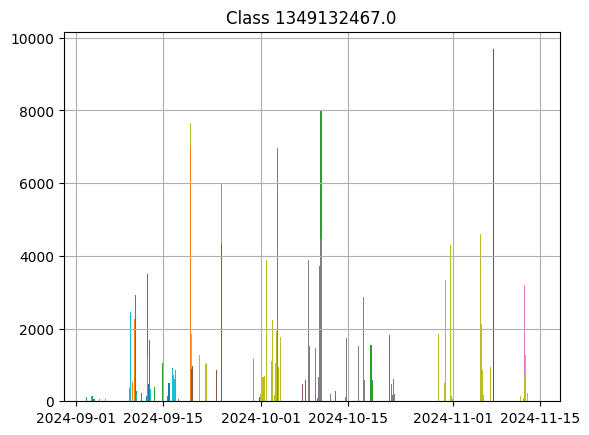

In [10]:
if "X-ClassID" not in main_table.columns:
    main_table.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
else:
    classes = main_table["X-ClassID"].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table["X-ClassID"] == class_id]
        hist = subset.groupby(Cols.AssignmentID)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        plt.show()

In [11]:
import numpy as np
for i in main_table[Cols.ServerTimestamp].quantile(np.arange(0, 1.01, 0.01)).to_list():
    print(i)

2024-09-01 01:35:32.500000
2024-09-09 14:55:15.499750144
2024-09-09 22:40:18.527000064
2024-09-10 15:48:46.463749888
2024-09-10 19:23:54.851000064
2024-09-10 22:58:02.735500032
2024-09-11 02:59:40.511500032
2024-09-11 14:23:44.017499904
2024-09-11 17:14:52.190000128
2024-09-11 18:40:13.632750080
2024-09-12 00:09:40.865500160
2024-09-12 18:10:06.244250112
2024-09-12 19:32:21.510000128
2024-09-13 02:33:10.078499840
2024-09-16 00:49:04.368999936
2024-09-16 17:04:16.838000128
2024-09-16 19:21:29.988000
2024-09-17 01:07:06.188000
2024-09-17 15:15:54.643500032
2024-09-17 18:14:53.639500032
2024-09-17 19:12:55.940999936
2024-09-17 23:03:06.654249984
2024-09-18 15:19:50.046499840
2024-09-18 19:05:38.106249984
2024-09-19 00:38:00.364000
2024-09-19 18:29:07.789749760
2024-09-19 20:38:19.884499968
2024-09-20 20:41:35.181750016
2024-09-21 23:59:54.903000064
2024-09-23 13:10:43.831500032
2024-09-23 17:14:37.292499968
2024-09-23 19:07:54.889999872
2024-09-24 00:52:04.836000
2024-09-24 18:20:04.82624

In [37]:
#get the data of the third quantile
max = main_table[Cols.ServerTimestamp].max()
min = main_table[Cols.ServerTimestamp].min()
range = max - min
time_cutoff = min + range * early_percentage
print(time_cutoff)
print(main_table[Cols.ServerTimestamp].min())
print(main_table[Cols.ServerTimestamp].max())

data_subset = main_table[main_table[Cols.ServerTimestamp] <= time_cutoff]
print("Assignment IDs:", data_subset[Cols.AssignmentID].unique())
print("Problem IDs:", data_subset[Cols.ProblemID].unique())
print("Total number of rows:", len(data_subset))
# Assignment IDs: [597 600]
# Problem IDs: [13 232 235 234 236   5 233   1   3  12  24 100 101  25 102  28  21  20  17  22]

2024-09-22 03:30:01.756800
2024-09-01 01:35:32.500000
2024-11-15 08:24:25.560000
Assignment IDs: [2.61168503e+09            nan 2.01335709e+09 4.27067005e+09
 1.36085055e+09 1.36006365e+09 3.09679449e+09 3.46621932e+09
 1.98032895e+09 2.90983374e+08 5.85776055e+08 1.99881010e+07
 5.58149337e+08 7.59078646e+08 2.14537607e+09 1.19249144e+08
 2.40815043e+08 2.74582803e+09 3.68109256e+08 2.78087063e+09
 3.91324454e+09 2.14815632e+09 1.70419381e+09 1.03734466e+09
 2.49103774e+08 3.97028108e+09 1.89665852e+09 4.59282688e+08
 1.42445494e+09 5.37498399e+08 4.19534388e+09 2.64970633e+09
 6.31605243e+08 1.79874337e+09 1.53863738e+09 2.77068275e+09
 1.67328901e+09 2.63606915e+08 1.46735927e+09 2.39917035e+09
 2.46122119e+09 1.94310873e+09 2.45531908e+09 2.56441098e+09
 3.78444757e+09 3.21038643e+09 4.07059535e+09 1.98739987e+09]
Problem IDs: [3.90279466e+09            nan 2.11162095e+08 3.78836843e+09
 3.94019784e+09 2.13296653e+09 4.23386584e+09 7.04983377e+08
 2.65057258e+09 3.44441700e+09 3.22

In [38]:
testing_student_subset = data_subset[Cols.SubjectID].unique()[:50]
testing_mt_subset = data_subset[data_subset[Cols.SubjectID].isin(testing_student_subset)]

In [118]:
grouping_cols = ["X-ClassID", Cols.SubjectID, problem_id_col]
grouping_cols = [col for col in grouping_cols if col in main_table.columns]

In [119]:
main_table.EventType[~main_table[compile_error_type_col].isna()].value_counts()

EventType
Run.Test    132672
Name: count, dtype: int64

In [120]:
from analytics.metrics.errors import ErrorMetrics


error_metrics = ErrorMetrics(True,
                             compile_message_type_column=compile_error_type_col,
                             compile_event=compile_event,
                             compile_error_event=compile_error_event)

error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
error_results.head()

C:\Users\twprice\AppData\Local\Temp\ipykernel_16768\4122987523.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)


ErrorQuotient  RepeatedErrorDensity
X-ClassID   SubjectID ProblemID                                        
945591435.0 112044560 1.927447e+09            NaN                   NaN
            158242931 1.057322e+09            NaN                   NaN
                      2.559670e+09            NaN                   NaN
                      3.968058e+09            1.0                   0.5
            188644686 1.463363e+08            NaN                   NaN

In [121]:
# EQ is very low for codebench because most runs have no errors
# It's interesting/odd that EQ and RED don't correlate on this dataset

error_results.describe()

,ErrorQuotient,RepeatedErrorDensity
count,3198.000000,3198.000000
mean,0.970470,4.562117
std,0.066520,9.092452
min,0.727273,0.000000
25%,0.981965,0.500000
50%,1.000000,1.333333
75%,1.000000,5.142857
max,1.000000,207.022234


In [122]:
error_results.corr(method="spearman")

,ErrorQuotient,RepeatedErrorDensity
ErrorQuotient,1.000000,0.032588
RepeatedErrorDensity,0.032588,1.000000


<Axes: ylabel='Frequency'>

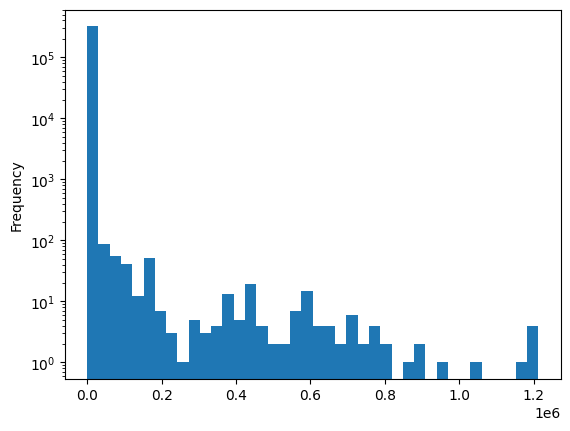

In [123]:
from analytics.metrics.time import TimeMetrics


diffs = TimeMetrics.get_all_diffs(testing_mt_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [124]:
TimeMetrics.get_positive_diff_quantiles(data_subset, timestamp_col, grouping_cols) / 60

# Seems like 5 minutes (90th+ percentile) is a good cutoff for time spent on a problem between submissions
# 30m does seem to suggest that the student is not working on the problem

0.00        0.000017
0.25        0.002933
0.50        0.006483
0.75        0.022183
0.80        0.029333
0.85        0.040700
0.90        0.062867
0.95        0.143417
0.96        0.190000
0.97        0.271567
0.98        0.441946
0.99        0.960000
1.00    20253.148250
Name: DeltaSeconds, dtype: float64

In [125]:
from analytics.metrics.time import TimeMetrics

time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
result

C:\Users\twprice\AppData\Local\Temp\ipykernel_16768\3223447471.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  TotalTime  \
X-ClassID    SubjectID  ProblemID                                          
9.455914e+08 112044560  1.927447e+09      10.374        0.000     10.374   
             158242931  1.057322e+09     173.882      364.659    538.541   
                        2.559670e+09      82.485       44.671    127.156   
                        3.968058e+09    1012.089      889.924   1902.013   
             188644686  1.463363e+08       0.000        0.000      0.000   
...                                          ...          ...        ...   
3.758479e+09 4215855445 1.092214e+09     143.695       49.690    193.385   
                        1.210323e+09      34.174        0.000     34.174   
                        1.934415e+09       0.000        0.000      0.000   
                        3.306862e+09     132.467        0.000    132.467   
                        4.011688e+09       0.000        0.000      0.000   

                                      ActiveTimeAfterCorrect  #Breaks  \
X-ClassID    SubjectID  ProblemID                                       
9.455914e+08 112044560  1.927447e+09                   0.000        0   
             158242931  1.057322e+09                   0.000        0   
                        2.559670e+09                   0.000        2   
                        3.968058e+09                   4.415        1   
             188644686  1.463363e+08                   0.000        0   
...                                                      ...      ...   
3.758479e+09 4215855445 1.092214e+09                   0.000        0   
                        1.210323e+09                   0.000        0   
                        1.934415e+09                   0.000        0   
                        3.306862e+09                   0.000        0   
                        4.011688e+09                   0.000        0   

                                                   StartTime  \
X-ClassID    SubjectID  ProblemID                              
9.455914e+08 112044560  1.927447e+09 2024-09-12 23:24:18.089   
             158242931  1.057322e+09 2024-09-17 22:58:08.625   
                        2.559670e+09 2024-09-17 22:36:34.682   
                        3.968058e+09 2024-09-17 22:16:09.607   
             188644686  1.463363e+08 2024-09-03 22:26:43.720   
...                                                      ...   
3.758479e+09 4215855445 1.092214e+09 2024-09-11 14:13:03.675   
                        1.210323e+09 2024-09-11 14:05:27.536   
                        1.934415e+09 2024-09-04 14:41:17.410   
                        3.306862e+09 2024-09-11 14:10:40.523   
                        4.011688e+09 2024-09-04 14:39:55.670   

                                            FirstCorrectTime  \
X-ClassID    SubjectID  ProblemID                              
9.455914e+08 112044560  1.927447e+09                     NaT   
             158242931  1.057322e+09                     NaT   
                        2.559670e+09                     NaT   
                        3.968058e+09 2024-09-17 22:52:24.660   
             188644686  1.463363e+08 2024-09-03 22:26:43.720   
...                                                      ...   
3.758479e+09 4215855445 1.092214e+09 2024-09-11 14:16:17.060   
                        1.210323e+09 2024-09-11 14:06:01.710   
                        1.934415e+09 2024-09-04 14:41:17.410   
                        3.306862e+09 2024-09-11 14:12:52.990   
                        4.011688e+09 2024-09-04 14:39:55.670   

                                                     EndTime  
X-ClassID    SubjectID  ProblemID                             
9.455914e+08 112044560  1.927447e+09 2024-09-12 23:24:28.463  
             158242931  1.057322e+09 2024-09-17 23:07:07.166  
                        2.559670e+09 2024-09-17 22:53:20.064  
                        3.968058e+09 2024-09-17 22:58:05.066  
             188644686  1.463363e+08 2024-09-03 22:26:4

In [126]:
result.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,6.792000e+03,6792.000000,6792.000000,6792.000000,6792.000000,6792,6018,6792
mean,2.538241e+02,156.924129,410.748275,8.816072,0.599382,2024-09-11 01:32:23.905096192,2024-09-10 20:11:36.727889920,2024-09-11 14:53:24.504618240
min,-5.684342e-14,0.000000,0.000000,0.000000,0.000000,2024-09-01 01:35:32.500000,2024-09-01 03:52:26.560000,2024-09-01 03:52:26.560000
25%,0.000000e+00,0.000000,4.550500,0.000000,0.000000,2024-09-04 19:01:26.667500032,2024-09-04 18:48:42.929999872,2024-09-05 01:54:36.795000064
50%,1.253660e+02,46.600500,195.968500,0.000000,0.000000,2024-09-11 01:21:35.782499840,2024-09-10 23:23:46.580000256,2024-09-11 15:00:07.090000128
75%,3.618603e+02,198.869500,548.264750,0.000000,1.000000,2024-09-16 23:17:45.872000,2024-09-16 19:07:47.302500096,2024-09-17 13:31:55.855000064
max,6.947802e+03,6630.387000,13578.189000,1452.270000,51.000000,2024-09-22 02:03:08.169000,2024-09-22 02:20:03.840000,2024-09-22 02:23:47.927000
std,3.890180e+02,294.019550,641.698711,48.120845,1.490900,NaN,NaN,NaN


In [127]:
from analytics.metrics.score import SubmissionScoreMetrics
from spec.enums import EventType

score_metrics = SubmissionScoreMetrics(submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_16768\1178317524.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [128]:
subject_problem_score.head()

Attempts  FirstCorrect  EverCorrect  \
X-ClassID   SubjectID ProblemID                                           
945591435.0 112044560 1.927447e+09         0         False        False   
            158242931 1.057322e+09         0         False        False   
                      2.559670e+09         0         False        False   
                      3.968058e+09         1          True         True   
            188644686 1.463363e+08         1          True         True   

                                    Attempted  MaxScore  MinScore  MeanScore  \
X-ClassID   SubjectID ProblemID                                                
945591435.0 112044560 1.927447e+09      False       0.0       0.0        0.0   
            158242931 1.057322e+09      False       0.0       0.0        0.0   
                      2.559670e+09      False       0.0       0.0        0.0   
                      3.968058e+09       True       1.0       1.0        1.0   
            188644686 1.463363e+08       True       1.0       1.0        1.0   

                                    TotalAttempts  
X-ClassID   SubjectID ProblemID                    
945591435.0 112044560 1.927447e+09              0  
            158242931 1.057322e+09              0  
                      2.559670e+09              0  
                      3.968058e+09              2  
            188644686 1.463363e+08              1

In [129]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,6792.000000,6792.000000,6792.000000,6792.000000,6792.000000
mean,3.356743,0.888840,0.532538,0.642504,3.686837
std,7.182976,0.312422,0.491477,0.400778,7.512253
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.250000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000
75%,3.000000,1.000000,1.000000,1.000000,3.000000
max,212.000000,1.000000,1.000000,1.000000,212.000000


In [130]:
all_features = pd.merge(
    result.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features = pd.merge(
    all_features,
    error_results.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features.head()

,X-ClassID,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity
0,945591435.0,112044560,1.927447e+09,10.374,0.000,10.374,0.000,0,2024-09-12 23:24:18.089,NaT,...,0,False,False,False,0.0,0.0,0.0,0,NaN,NaN
1,945591435.0,158242931,1.057322e+09,173.882,364.659,538.541,0.000,0,2024-09-17 22:58:08.625,NaT,...,0,False,False,False,0.0,0.0,0.0,0,NaN,NaN
2,945591435.0,158242931,2.559670e+09,82.485,44.671,127.156,0.000,2,2024-09-17 22:36:34.682,NaT,...,0,False,False,False,0.0,0.0,0.0,0,NaN,NaN
3,945591435.0,158242931,3.968058e+09,1012.089,889.924,1902.013,4.415,1,2024-09-17 22:16:09.607,2024-09-17 22:52:24.660,...,1,True,True,True,1.0,1.0,1.0,2,1.0,0.5
4,945591435.0,188644686,1.463363e+08,0.000,0.000,0.000,0.000,0,2024-09-03 22:26:43.720,2024-09-03 22:26:43.720,...,1,True,True,True,1.0,1.0,1.0,1,NaN,NaN


In [131]:
all_features.isna().mean()

X-ClassID                 0.000000
SubjectID                 0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.113958
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
TotalAttempts             0.000000
ErrorQuotient             0.529152
RepeatedErrorDensity      0.529152
dtype: float64

In [132]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,X-ClassID,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,6.792000e+03,6.792000e+03,6.792000e+03,6.792000e+03,6792.000000,6792.000000,6792.000000,6792.000000,6792,6018,...,6792.000000,6792.000000,6792.000000,6792.000000,6792.000000,3198.000000,3198.000000,6792.000000,6792.000000,6792.000000
mean,2.728857e+09,2.138654e+09,2.152917e+09,2.538241e+02,156.924129,410.748275,8.816072,0.599382,2024-09-11 01:32:23.905096192,2024-09-10 20:11:36.727889920,...,3.356743,0.888840,0.532538,0.642504,3.686837,0.970470,4.562117,0.594081,0.889429,0.946996
min,9.455914e+08,1.310882e+07,4.868418e+07,-5.684342e-14,0.000000,0.000000,0.000000,0.000000,2024-09-01 01:35:32.500000,2024-09-01 03:52:26.560000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.727273,0.000000,0.000000,0.000000,0.000000
25%,2.298943e+09,1.008349e+09,1.050674e+09,0.000000e+00,0.000000,4.550500,0.000000,0.000000,2024-09-04 19:01:26.667500032,2024-09-04 18:48:42.929999872,...,1.000000,1.000000,0.000000,0.250000,1.000000,0.981965,0.500000,0.000000,1.000000,1.000000
50%,2.607741e+09,2.164738e+09,2.086142e+09,1.253660e+02,46.600500,195.968500,0.000000,0.000000,2024-09-11 01:21:35.782499840,2024-09-10 23:23:46.580000256,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.333333,1.000000,1.000000,1.000000
75%,3.648409e+09,3.156312e+09,3.455942e+09,3.618603e+02,198.869500,548.264750,0.000000,1.000000,2024-09-16 23:17:45.872000,2024-09-16 19:07:47.302500096,...,3.000000,1.000000,1.000000,1.000000,3.000000,1.000000,5.142857,1.000000,1.000000,1.000000
max,3.758479e+09,4.275215e+09,4.233866e+09,6.947802e+03,6630.387000,13578.189000,1452.270000,51.000000,2024-09-22 02:03:08.169000,2024-09-22 02:20:03.840000,...,212.000000,1.000000,1.000000,1.000000,212.000000,1.000000,207.022234,1.000000,1.000000,1.000000
std,1.027854e+09,1.255840e+09,1.336297e+09,3.890180e+02,294.019550,641.698711,48.120845,1.490900,NaN,NaN,...,7.182976,0.312422,0.491477,0.400778,7.512253,0.066520,9.092452,0.491105,0.313624,0.224057


In [133]:
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [134]:
all_features_z.head()

,X-ClassID,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,945591435.0,112044560,1.927447e+09,-0.494177,-0.569686,-0.561906,-0.175849,-0.478578,1.677975,-3.215685,...,False,-3.215685,-1.028469,-1.602820,-0.730212,NaN,NaN,0.000000,-3.215685,0.000000
1,945591435.0,158242931,1.057322e+09,-0.410158,0.304318,-0.143141,-0.348785,-0.578088,1.212428,-1.313579,...,False,-1.313579,-0.716498,-1.034503,-0.746534,NaN,NaN,-1.028992,-1.313579,-1.313579
2,945591435.0,158242931,2.559670e+09,-0.991146,-0.754208,-0.980870,-0.476213,1.292837,1.353819,-1.845200,...,False,-1.845200,-0.503236,-1.129168,-1.009688,NaN,NaN,-0.963624,-1.845200,-1.845200
3,945591435.0,158242931,3.968058e+09,1.155538,2.217921,1.667202,0.029898,0.298541,0.673027,0.449136,...,True,0.449089,0.914659,0.865124,-0.314786,0.806915,-0.549511,0.914659,0.449089,0.242536
4,945591435.0,188644686,1.463363e+08,-0.499051,-0.567312,-0.559024,-0.187739,-0.463748,-0.663373,0.329387,...,True,0.329469,1.098231,1.039117,-0.580941,NaN,NaN,-1.005479,0.329469,0.239793


In [135]:
all_features_z.RepeatedErrorDensity.isna().mean()

np.float64(0.5291519434628975)

In [136]:
all_na_eq = all_features.groupby(Cols.SubjectID).ErrorQuotient.apply(lambda x: pd.isna(x).all())
all_na_eq = all_na_eq[all_na_eq]
all_na_eq

SubjectID
112044560     True
168966594     True
287168727     True
456016787     True
477252290     True
955045871     True
1017475257    True
1175763119    True
1214728740    True
1400890297    True
1489631879    True
1584616107    True
1682474731    True
1693698062    True
1712920939    True
2371903107    True
2388256559    True
2596793261    True
2788499525    True
2803773334    True
2808189831    True
2808222414    True
2947028959    True
3026032920    True
3429343515    True
3449088692    True
3624632776    True
3657519975    True
4185351836    True
4200061691    True
4207632686    True
Name: ErrorQuotient, dtype: bool

In [137]:
# In CWO, this student attempted all of 1 problem, got and error and gave up
# I think assigning a 1 makes more sense than a 0... but 0 is more generic and
# it's rare enough I'm not going to worry about it right now
data_subset[data_subset[Cols.SubjectID].isin(all_na_eq.index)]

,EventID,EventType,Order,SubjectID,CodeStateID,ProjectID,ToolInstances,ServerTimestamp,AssignmentID,ProblemID,...,ExecutionResult,X-ExecutionTime,ProgramInput,ProgramOutput,ProgramErrorOutput,EditType,X-InsertText,SourceLocation,CodeStateSection,ParentEventID
30334,76340,Session.Start,30334,2808189831,NaN,NaN,NaN,2024-09-02 14:33:35.790,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30593,76438,Session.End,30593,2808189831,NaN,NaN,NaN,2024-09-02 14:46:46.680,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34974,78374,Session.Start,34974,3624632776,NaN,NaN,NaN,2024-09-02 20:29:51.580,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35904,78879,Session.Start,35904,2803773334,NaN,NaN,NaN,2024-09-03 12:00:20.310,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35905,6148,Submit,35905,2803773334,f5bb87a936a7855a21d02d5b066b26475d6daceb,119249144_1467685783,Python 3.8.5,2024-09-03 12:01:58.460,119249144.0,1.467686e+09,...,NaN,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1328117,151795,Session.Start,1328117,2596793261,NaN,NaN,NaN,2024-09-20 14:57:43.170,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1328315,151810,Session.Start,1328315,2596793261,NaN,NaN,NaN,2024-09-20 15:10:30.070,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1328917,151840,Session.Start,1328917,2596793261,NaN,NaN,NaN,2024-09-20 15:26:54.700,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1329233,151852,Session.End,1329233,2596793261,NaN,NaN,NaN,2024-09-20 15:29:08.400,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [152]:
merge_cols = grouping_cols.copy()
merge_cols.remove(problem_id_col)
merge_cols = [col for col in merge_cols if col in all_features_z.columns]

subject_means = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).mean()
# In theory this can happen is someone only has NA for all problems
# This apparently happened with EQ in CWO...

# For EQ, having no attempts with compile errors should give you
# the max value (whatever 1 is after normalization)
for col in [ErrorMetrics.ERROR_QUOTIENT]:
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for RED it should be the minimum value (normalized 0)
for col in [ErrorMetrics.REPEATED_ERROR_DENSITY]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

ActiveTime  PassiveTime  TotalTime  \
X-ClassID   SubjectID                                       
945591435.0 112044560   -0.494177    -0.569686  -0.561906   
            158242931   -0.081922     0.589344   0.181064   
            188644686   -0.492325    -0.410954  -0.510523   
            280846303   -0.380819    -0.482743  -0.437578   
            414686080    0.988681     0.706244   0.937261   

                       ActiveTimeAfterCorrect   #Breaks  StartTime  \
X-ClassID   SubjectID                                                
945591435.0 112044560               -0.175849 -0.478578   1.677975   
            158242931               -0.265033  0.337763   1.079758   
            188644686               -0.219057 -0.357268  -0.641676   
            280846303               -0.246561 -0.266315   0.982964   
            414686080               -0.170824  0.363983   0.565273   

                       FirstCorrectTime   EndTime  Attempts  FirstCorrect  \
X-ClassID   SubjectID                                                       
945591435.0 112044560         -3.215685  1.274810 -0.691515      0.000000   
            158242931         -0.903214  1.081290 -0.718592      0.333333   
            188644686          0.243919 -0.774720 -0.338836      0.727273   
            280846303         -3.606372  0.663749 -0.320550      0.000000   
            414686080         -0.214907  0.480995  0.218798      0.304348   

                       ...  Attempted  MaxScore  MinScore  MeanScore  \
X-ClassID   SubjectID  ...                                             
945591435.0 112044560  ...   0.000000 -3.215685 -1.028469  -1.602820   
            158242931  ...   0.333333 -0.903230 -0.101692  -0.432849   
            188644686  ...   1.000000  0.279475  0.421797   0.515825   
            280846303  ...   0.000000 -3.758503 -0.966686  -1.669050   
            414686080  ...   0.869565 -0.224466 -0.481391  -0.500671   

                       TotalAttempts  ErrorQuotient  RepeatedErrorDensity  \
X-ClassID   SubjectID                                                       
945591435.0 112044560      -0.730212       0.931488             -0.733408   
            158242931      -0.690336       0.806915             -0.549511   
            188644686      -0.354754      -0.440253             -0.462734   
            280846303      -0.337874       0.931488             -0.733408   
            414686080       0.149776       0.196823              0.232660   

                       AtLeatMedianActiveTime  AtLeatMedianMaxScore  HadEffort  
X-ClassID   SubjectID                                                           
945591435.0 112044560                0.000000             -3.215685   0.000000  
            158242931               -0.359319             -0.903230  -0.972081  
            188644686               -0.451832              0.279475   0.091956  
            280846303                0.991155             -3.606372   0.155238  
            414686080                0.555661             -0.227483   0.117555  

[5 rows x 21 columns]

In [153]:
subject_totals = all_features_z.drop(problem_id_col, axis=1).groupby(merge_cols).sum()
subject_totals.head()

ActiveTime  PassiveTime  TotalTime  \
X-ClassID   SubjectID                                       
945591435.0 112044560   -0.494177    -0.569686  -0.561906   
            158242931   -0.245766     1.768031   0.543192   
            188644686  -10.831146    -9.040990 -11.231504   
            280846303   -0.380819    -0.482743  -0.437578   
            414686080   45.479304    32.487201  43.113994   

                       ActiveTimeAfterCorrect    #Breaks  StartTime  \
X-ClassID   SubjectID                                                 
945591435.0 112044560               -0.175849  -0.478578   1.677975   
            158242931               -0.795100   1.013290   3.239274   
            188644686               -4.819251  -7.859897 -14.116882   
            280846303               -0.246561  -0.266315   0.982964   
            414686080               -7.857883  16.743241  26.002553   

                       FirstCorrectTime    EndTime   Attempts  FirstCorrect  \
X-ClassID   SubjectID                                                         
945591435.0 112044560         -3.215685   1.274810  -0.691515             0   
            158242931         -2.709643   3.243871  -2.155776             1   
            188644686          5.366221 -17.043834  -7.454400            16   
            280846303         -3.606372   0.663749  -0.320550             0   
            414686080         -9.885744  22.125771  10.064712            14   

                       ...  Attempted   MaxScore   MinScore  MeanScore  \
X-ClassID   SubjectID  ...                                               
945591435.0 112044560  ...          0  -3.215685  -1.028469  -1.602820   
            158242931  ...          1  -2.709690  -0.305075  -1.298547   
            188644686  ...         22   6.148448   9.279542  11.348147   
            280846303  ...          0  -3.758503  -0.966686  -1.669050   
            414686080  ...         40 -10.325448 -22.143995 -23.030847   

                       TotalAttempts  ErrorQuotient  RepeatedErrorDensity  \
X-ClassID   SubjectID                                                       
945591435.0 112044560      -0.730212       0.000000              0.000000   
            158242931      -2.071009       0.806915             -0.549511   
            188644686      -7.804580      -3.522023             -3.701875   
            280846303      -0.337874       0.000000              0.000000   
            414686080       6.889692       4.723758              5.583834   

                       AtLeatMedianActiveTime  AtLeatMedianMaxScore  HadEffort  
X-ClassID   SubjectID                                                           
945591435.0 112044560                0.000000             -3.215685   0.000000  
            158242931               -1.077957             -2.709690  -2.916243  
            188644686               -9.940308              6.148448   2.023041  
            280846303                0.991155             -3.606372   0.155238  
            414686080               25.560396            -10.464214   5.407520  

[5 rows x 21 columns]

In [154]:
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,945591435.0,112044560,-0.494177,-0.569686,-0.561906,-0.175849,-0.478578,1.677975,-3.215685,1.274810,...,0,-3.215685,-1.028469,-1.602820,-0.730212,0.000000,0.000000,0.000000,-3.215685,0.000000
1,945591435.0,158242931,-0.081922,0.589344,0.181064,-0.265033,0.337763,1.079758,-0.903214,1.081290,...,1,-2.709690,-0.305075,-1.298547,-2.071009,0.806915,-0.549511,-1.077957,-2.709690,-2.916243
2,945591435.0,188644686,-0.492325,-0.410954,-0.510523,-0.219057,-0.357268,-0.641676,0.243919,-0.774720,...,22,6.148448,9.279542,11.348147,-7.804580,-3.522023,-3.701875,-9.940308,6.148448,2.023041
3,945591435.0,280846303,-0.380819,-0.482743,-0.437578,-0.246561,-0.266315,0.982964,-3.606372,0.663749,...,0,-3.758503,-0.966686,-1.669050,-0.337874,0.000000,0.000000,0.991155,-3.606372,0.155238
4,945591435.0,414686080,0.988681,0.706244,0.937261,-0.170824,0.363983,0.565273,-0.214907,0.480995,...,40,-10.325448,-22.143995,-23.030847,6.889692,4.723758,5.583834,25.560396,-10.464214,5.407520


In [155]:
assert subject_features.isna().mean().mean() == 0

In [156]:
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,945591435.0,112044560,-0.529262,-0.855576,-0.666057,-0.274057,-0.856494,2.046356,-1.798528,1.694058,...,-1.203326,-0.339671,-0.085582,-0.123853,-0.060152,-8.952649e-17,2.270647e-17,3.489184e-17,-0.341826,0.000000
1,945591435.0,158242931,0.167663,1.423357,0.603589,-0.566327,1.178000,1.270447,-0.106331,1.428937,...,-1.151024,-0.286223,-0.025386,-0.100341,-0.170601,2.338389e-01,-8.077813e-02,-9.131119e-02,-0.288039,-0.444761
2,945591435.0,188644686,-0.526130,-0.543470,-0.578249,-0.415655,-0.554165,-0.962316,0.733106,-1.113780,...,-0.052681,0.649457,0.772179,0.876892,-0.642909,-1.020661e+00,-5.441756e-01,-8.420204e-01,0.653578,0.308537
3,945591435.0,280846303,-0.337628,-0.684624,-0.453594,-0.505791,-0.327492,1.144902,-2.084420,0.856909,...,-1.203326,-0.397008,-0.080441,-0.128971,-0.027833,-8.952649e-17,2.270647e-17,8.395841e-02,-0.383356,0.023676
4,945591435.0,414686080,1.977535,1.653210,1.895838,-0.257587,1.243346,0.603141,0.397351,0.606538,...,0.888755,-1.090671,-1.842669,-1.779635,0.567544,1.368916e+00,8.208236e-01,2.165162e+00,-1.112342,0.824709


In [158]:
grades = dataset.get_link_table(grades_link_table)
grades.head()

,CourseID,SubjectID,URL,approved,final-grade
0,919753123,2596793261,Resources/FinalGrade/919753123_2596793261.yaml,False,0.00
1,919753123,3143505766,Resources/FinalGrade/919753123_3143505766.yaml,False,0.00
2,919753123,3624632776,Resources/FinalGrade/919753123_3624632776.yaml,False,0.44
3,919753123,3215542955,Resources/FinalGrade/919753123_3215542955.yaml,False,3.38
4,919753123,904953019,Resources/FinalGrade/919753123_904953019.yaml,False,0.00


In [ ]:
grades.rename(columns={
    grades_col: "Grade", "CourseID":
    # CodeBench has this mislabeled
    "X-ClassID"},
inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 189 rows with 0 grades


In [160]:
print(f"Merging on columns: {merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[merge_cols + ["Grade"]],
    on=merge_cols,
    how="inner",
)

Merging on columns: ['X-ClassID', <MainTableColumns.SubjectID: 'SubjectID'>]


In [161]:
subject_feautres_labeled.head()

,X-ClassID,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,945591435.0,158242931,0.167663,1.423357,0.603589,-0.566327,1.178000,1.270447,-0.106331,1.428937,...,-0.286223,-0.025386,-0.100341,-0.170601,0.233839,-0.080778,-0.091311,-0.288039,-0.444761,1.49
1,945591435.0,188644686,-0.526130,-0.543470,-0.578249,-0.415655,-0.554165,-0.962316,0.733106,-1.113780,...,0.649457,0.772179,0.876892,-0.642909,-1.020661,-0.544176,-0.842020,0.653578,0.308537,8.75
2,945591435.0,414686080,1.977535,1.653210,1.895838,-0.257587,1.243346,0.603141,0.397351,0.606538,...,-1.090671,-1.842669,-1.779635,0.567544,1.368916,0.820824,2.165162,-1.112342,0.824709,5.66
3,945591435.0,530793764,0.986522,1.203113,1.069224,-0.145359,0.346904,0.583563,0.417594,0.581460,...,-0.618220,0.548531,0.344377,-0.816364,0.246179,-0.525786,0.331814,-0.613979,-0.077464,3.12
4,945591435.0,873175644,2.185542,2.277444,2.120679,-0.785217,0.136957,1.585580,-1.055829,1.564655,...,-0.464928,-0.160575,-0.199926,0.278511,0.158734,0.360290,0.089506,-0.467878,0.052402,3.42


In [162]:
print(len(subject_feautres_labeled))
dir = os.path.join(dataset.data_config.root_path, "analysis")
if not os.path.exists(dir):
    os.makedirs(dir)
subject_feautres_labeled.to_csv(os.path.join(dir, "subject_features.csv"), index=False)

207
